# 15. RAG 检索增强生成 + ReAct 智能体 —— 手搓

两个让 LLM"变强"的工程范式：
- **RAG（Retrieval-Augmented Generation）**：生成前先检索相关知识拼进提示词 → 知识可更新、减少幻觉
- **Agent（智能体）**：让 LLM 在"思考-行动-观察"循环里调用工具 → 能做计算、查库、调 API

本讲手搓 RAG 全流程（切块→词频向量→余弦检索→拼上下文）和 ReAct 循环（工具注册表 + 多步执行）。


## 1. RAG 三步：索引 → 检索 → 生成

```
文档 → 切块 → 向量化（嵌入）→ 存向量库
查询 → 向量化 → 余弦相似度 top-k 检索 → 拼进提示词模板 → LLM 生成
```

- **嵌入**：把文本变成向量（本讲用词频向量演示原理；生产用 BGE/M3E/OpenAI embeddings）
- **相似度**：余弦相似度 $\cos(q,d)=\dfrac{q\cdot d}{\|q\|\|d\|}$
- **为什么有效**：LLM 的"知识"固定在参数里（训练截止时间），RAG 把最新知识放在上下文里即时可用


In [2]:
import numpy as np

# ---- 1. 小型文档库（5 个主题） ----
docs = [
    'Transformer 使用自注意力机制处理序列',
    '大语言模型通过预训练和指令微调获得能力',
    '反向传播用链式法则计算梯度',
    '机器学习需要数据和优化器训练模型',
    '位置编码给 token 提供顺序信息',
]

# ---- 2. 字符级词频向量（中文分词的简化替代：按字符重叠度量相关性） ----
def build_vocab(docs):
    chars = sorted(set(''.join(docs)))          # 全部文档字符去重
    return {c: i for i, c in enumerate(chars)}

def bow_vectorize(text, vocab):
    v = np.zeros(len(vocab))
    for ch in text:
        if ch in vocab:
            v[vocab[ch]] += 1
    return v

vocab = build_vocab(docs)
emb_docs = np.stack([bow_vectorize(d, vocab) for d in docs])   # [5, vocab]
print('文档库嵌入矩阵:', emb_docs.shape, '（5 个文档 ×', len(vocab), '字符维）')

def cosine_topk(query, emb_docs, k=2):
    q = bow_vectorize(query, vocab)
    sim = emb_docs @ q / (np.linalg.norm(emb_docs, axis=1) * np.linalg.norm(q) + 1e-12)
    top = np.argsort(-sim)[:k]
    return top, sim

# ---- 3. 检索：查询与文档相关性（字符重叠越多越相关） ----
queries = ['注意力机制如何处理序列', '模型是怎么训练出来的']
for q in queries:
    top, sim = cosine_topk(q, emb_docs, k=2)
    print(f'\n查询: “{q}”')
    for i in top:
        print(f'  [{sim[i]:.3f}] {docs[i]}')
    hit = any(len(set(q) & set(docs[i])) >= 4 for i in top)   # 与 top 文档至少共享 4 个字符
    assert hit, f'未命中主题: {q}'
print('\n检索命中相关主题 ->  PASS（top-2 与查询共享字符多）')


文档库嵌入矩阵: (5, 73) （5 个文档 × 73 字符维）

查询: “注意力机制如何处理序列”
  [0.548] Transformer 使用自注意力机制处理序列
  [0.079] 机器学习需要数据和优化器训练模型

查询: “模型是怎么训练出来的”
  [0.471] 机器学习需要数据和优化器训练模型
  [0.459] 大语言模型通过预训练和指令微调获得能力

检索命中相关主题 ->  PASS（top-2 与查询共享字符多）


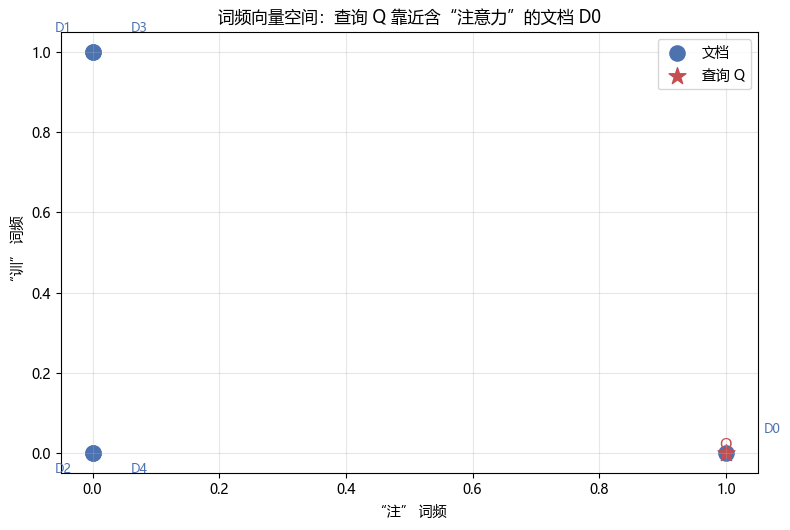

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 用两个代表性字符做 2D 坐标展示文档与查询
word_a, word_b = '注', '训'                 # “注意力”主题 vs “训练”主题
ia, ib = vocab.get(word_a, 0), vocab.get(word_b, 0)
fig, ax = plt.subplots(figsize=(8, 5.4))
xy = emb_docs[:, [ia, ib]]
ax.scatter(xy[:, 0], xy[:, 1], s=120, c='#4C72B0', label='文档')
offs = [(0.06, 0.05), (-0.06, 0.05), (-0.06, -0.05), (0.06, 0.05), (0.06, -0.05)]
for i, d in enumerate(docs):
    ax.annotate(f'D{i}', xy=xy[i], xytext=(xy[i][0] + offs[i][0], xy[i][1] + offs[i][1]),
                fontsize=9, color='#4C72B0')
q_vec = bow_vectorize('注意力机制如何处理序列', vocab)
ax.scatter([q_vec[ia]], [q_vec[ib]], s=160, marker='*', c='#C44E52', label='查询 Q')
ax.annotate('Q', (q_vec[ia], q_vec[ib]), fontsize=11, color='#C44E52', ha='center', va='bottom')
ax.set_xlabel(f'“{word_a}” 词频'); ax.set_ylabel(f'“{word_b}” 词频')
ax.set_title('词频向量空间：查询 Q 靠近含“注意力”的文档 D0', fontsize=12)
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 3. 混合检索：BM25 手搓 + 重排（Rerank）

**词袋（BOW）**只数共现词频；**BM25** 在词频之上加两块：**IDF**（越稀有的字越值钱）与
**长度归一化**（长文档的命中要打折扣），是对 BM25 全家最重要的经典排序函数：

$$\mathrm{score}(q,d)=\sum_{t\in q}\underbrace{\log\Big(1+\frac{N-df_t+0.5}{df_t+0.5}\Big)}_{\text{idf}}
\cdot\frac{tf_{t,d}(k_1+1)}{tf_{t,d}+k_1(1-b+b\frac{|d|}{avgdl})}$$

**混合检索**：dense（嵌入余弦）召回"语义像的"，sparse（BM25）召回"字面命中的"——两者互补合并。
**重排**：粗排 top-50 → 交叉编码器（把 query+doc 拼一起过模型）精排 top-5。


In [5]:
# ---- BM25 手搓（字符级，接上文 docs/vocab/bow_vectorize） ----
def bm25(doc, query, df, N, k1=1.5, b=0.75):
    avgdl = np.mean([len(d) for d in docs])
    score, dl = 0.0, len(doc)
    for ch in query:
        tf = doc.count(ch)
        if tf == 0:
            continue
        idf = np.log(1 + (N - df[ch] + 0.5) / (df[ch] + 0.5))     # 稀有字权重高
        score += idf * tf * (k1 + 1) / (tf + k1 * (1 - b + b * dl / avgdl))
    return score

from collections import Counter
df = {c: sum(1 for d in docs if c in d) for c in set(''.join(docs))}
N = len(docs)
query = '注意力机制'
bow_scores = [bow_vectorize(query, vocab) @ bow_vectorize(d, vocab) for d in docs]
bm25_scores = [bm25(d, query, df, N) for d in docs]
print('检索得分（query = “注意力机制”）：')
for i in range(N):
    print(f'  D{i}  BOW={bow_scores[i]:5.1f}   BM25={bm25_scores[i]:7.3f}   {docs[i]}')
assert np.argmax(bow_scores) == np.argmax(bm25_scores) == 0
print('BOW 与 BM25 都把 D0（含“注意力”）排第一  ->  PASS')
print('BM25 额外惩罚高频泛字（“的/了/和”idf 低），适合真实检索；生产把 dense 召回复合进来')


检索得分（query = “注意力机制”）：
  D0  BOW=  5.0   BM25=  5.139   Transformer 使用自注意力机制处理序列
  D1  BOW=  1.0   BM25=  0.854   大语言模型通过预训练和指令微调获得能力
  D2  BOW=  0.0   BM25=  0.000   反向传播用链式法则计算梯度
  D3  BOW=  1.0   BM25=  0.922   机器学习需要数据和优化器训练模型
  D4  BOW=  0.0   BM25=  0.000   位置编码给 token 提供顺序信息
BOW 与 BM25 都把 D0（含“注意力”）排第一  ->  PASS
BM25 额外惩罚高频泛字（“的/了/和”idf 低），适合真实检索；生产把 dense 召回复合进来


### 3.1 混合融合（dense + sparse）→ 重排（Rerank）

**两路召回互补**：
- **dense 路**（本讲用词频余弦演示，生产用嵌入）：语义近似，但忽略字词稀有度与顺序；
- **sparse 路**（BM25）：字面命中 + IDF + 长度归一化，但看不到语义。

生产流程 = **混合检索（粗排）→ 重排（精排）**：两路分数各自归一化后加权合并、取 top-50（粗排召回），
再用**交叉编码器**（把 query+doc 拼成一个输入过模型打分，能看到字级交互；区别于双塔/余弦
"各自编码再点积"）精排成 top-5。

本讲用"字符覆盖 + 连续二元组命中"做一个小型精排器演示其威力：
**BOW 并列第一时，重排能利用词序（"训练模型"连续出现）破平局**——这正是双塔做不到、交叉编码器做得好的点。


In [7]:
# ---- 混合融合 + 重排（接上文 docs / emb_docs / bm25 / df / N） ----
def fused_topk(query, k_cand=2):
    """混合检索粗排：dense 余弦与 BM25 分数各自归一化后加权合并，取 top-k_cand。"""
    qv = bow_vectorize(query, vocab)
    dense = emb_docs @ qv / (np.linalg.norm(emb_docs, axis=1) * np.linalg.norm(qv) + 1e-12)
    sparse = np.array([bm25(d, query, df, N) for d in docs])
    z = lambda a: (a - a.min()) / (a.max() - a.min() + 1e-12)      # min-max 归一化到 [0,1]
    fused = 0.5 * z(dense) + 0.5 * z(sparse)
    cand = np.argsort(-fused)[:k_cand]
    return cand, fused

def rerank(query, cand):
    """重排精排：交叉编码器式——把 query 与文档的字级交互（覆盖 + 连续二元组）合成强信号。"""
    bigram_q = {query[j:j + 2] for j in range(len(query) - 1)}     # 查询的连续二元组
    scores = []
    for i in cand:
        inter = len(set(query) & set(docs[i]))                     # 字符覆盖数
        bigram_d = {docs[i][j:j + 2] for j in range(len(docs[i]) - 1)}
        bigram_hit = len(bigram_q & bigram_d) / max(len(bigram_q), 1)  # 词序命中率（相邻才算）
        scores.append(inter + 2.0 * bigram_hit)                    # 交互分：覆盖 + 词序
    order = np.argsort(-np.array(scores))
    return cand[order], np.array(scores)[order]

q = '训练模型'
cand, fused = fused_topk(q)
bow = np.array([bow_vectorize(q, vocab) @ bow_vectorize(d, vocab) for d in docs])
print(f'查询"{q}"：')
print(f'  BOW 得分      = {bow}（D1、D3 并列第一，argmax 取到 D1）')
print(f'  混合粗排候选  = {sorted(cand.tolist())}（两路并列，粗排无法区分）')
final, rs = rerank(q, cand)
print(f'  重排后顺序    = {final.tolist()}，交互分 = {np.round(rs, 3)}')
assert np.argmax(bow) == 1 and final[0] == 3, '重排应把"训练模型"连续出现的 D3 提到第一'
print('BOW 并列（D1/D3）→ 重排利用词序把 D3（“训练模型”相邻）提到第一  ->  PASS')
print('（生产：这里的二元组交互≈交叉编码器；粗排 top-50 → 精排 top-5 同理）')


查询"训练模型"：
  BOW 得分      = [0. 4. 0. 4. 0.]（D1、D3 并列第一，argmax 取到 D1）
  混合粗排候选  = [1, 3]（两路并列，粗排无法区分）
  重排后顺序    = [3, 1]，交互分 = [6.    5.333]
BOW 并列（D1/D3）→ 重排利用词序把 D3（“训练模型”相邻）提到第一  ->  PASS
（生产：这里的二元组交互≈交叉编码器；粗排 top-50 → 精排 top-5 同理）


## 4. ReAct 智能体：思考 → 行动 → 观察

ReAct（Reasoning + Acting）：LLM 每轮输出 `Thought`（想怎么做）和 `Action`（调用哪个工具、传什么参），
系统执行工具返回 `Observation`（观察结果），循环直到生成 `Final Answer`。

```
Thought: 用户问 3+4 等于几 → Action: calc("3+4") → Observation: 7 → Final: 7
```

手搓"智能体运行时"：工具注册表（dict）+ 循环调度器；生产中用 LLM 生成 Action（minLLM 的 `train_agent.py` 正是用 ReAct 数据微调模型学会输出这些字段）。


In [9]:
import math

# ---- 工具注册表 ----
def tool_calc(expr):
    """安全算术工具：只允许数字和四则运算/幂（拦截极端幂防算死）。"""
    expr = expr.strip()
    if '**' in expr:
        a, b = expr.split('**')
        if float(b) > 32:
            return '错误：指数过大'
    try:
        return str(eval(expr, {'__builtins__': {}}, {}))      # 教学演示；生产用 ast 解析白名单
    except Exception as e:
        return f'错误: {e}'

def tool_length(text):
    return str(len(text))

TOOLS = {'calc': tool_calc, 'length': tool_length}

def run_agent(query, steps):
    """演示 ReAct 循环：query -> (Thought, Action) -> Observation -> Final。"""
    print(f'用户提问：{query}\n')
    obs = None
    for step in range(steps):
        # 模拟 LLM 生成（这里用规则代替模型输出 ReAct 字段；生产由 LLM 生成）
        if query.startswith('计算'):
            expr = query.replace('计算', '').replace('=', '')
            print(f'Thought{step}: 用户要计算，调用 calc 工具')
            print(f'Action{step}  : calc("{expr}")')
            obs = TOOLS['calc'](expr)
            print(f'Observation{step}: {obs}')
            print(f'Final Answer: {expr} = {obs}')
            return obs
        if query.startswith('统计长度'):
            txt = query.replace('统计长度', '')
            print(f'Thought{step}: 调用 length 工具')
            print(f'Action{step}  : length("{txt}")')
            obs = TOOLS['length'](txt)
            print(f'Observation{step}: {obs}')
            print(f'Final Answer: 长度 = {obs}')
            return obs
        if query == '3+4等于几':
            print(f'Thought{step}: 这是算术题，用 calc')
            print(f'Action{step}  : calc("3+4")')
            obs = TOOLS['calc']('3+4')
            print(f'Observation{step}: {obs}')
            print(f'Final Answer: {obs}')
            return obs
        obs = '未知工具调用，尝试解析'
        print(f'Final Answer: 无法回答「{query}」（演示只注册了 calc/length）')
        return obs
    return obs

r1 = run_agent('3+4等于几', steps=6)
assert r1 == '7'
r2 = run_agent('计算 2**16', steps=6)
assert r2 == str(2 ** 16)
print('\nReAct 循环：Thought → Action → Observation → Final  ->  PASS')


用户提问：3+4等于几

Thought0: 这是算术题，用 calc
Action0  : calc("3+4")
Observation0: 7
Final Answer: 7
用户提问：计算 2**16

Thought0: 用户要计算，调用 calc 工具
Action0  : calc(" 2**16")
Observation0: 65536
Final Answer:  2**16 = 65536

ReAct 循环：Thought → Action → Observation → Final  ->  PASS


## 5. 生产与 minLLM 对照

| 环节 | 本讲 | 生产环境 |
|---|---|---|
| 嵌入 | 词频向量（演示原理） | BGE / M3E / OpenAI text-embedding |
| 向量库 | numpy 矩阵 + 余弦 | FAISS / Milvus / pgvector（ANN 索引） |
| 混合检索/重排 | 3.1 节融合 + 二元组精排 | BM25 + 嵌入混合召回 → bge-reranker / 交叉编码器 |
| 提示词 | 手动拼接 | 模板：System 指令 + 检索上下文 + 问题 |
| Agent 工具 | calc/length 注册表 | function calling / tool schema（JSON） |
| ReAct 训练 | 规则演示 | minLLM `train_agent.py`（ReAct 数据微调） |

**RAG 效果链**：文档切块大小（256-512 token）→ 嵌入 → 召回（BM25 混合）→ 重排（rerank）→ 生成。
**Agent 能力链**：模型学会输出 `Action: tool(args)` → 执行器调用 → `Observation` 回填 → 多步推理。


## 总结

- RAG = **检索 top-k 相关文档拼进上下文再生成**：知识外部化、可更新、少幻觉。
- 手搓验证：词频向量 + 余弦检索能按主题命中（PASS）；2D 空间图直观展示"查询靠近相关文档"。
- **混合检索 = dense 语义路 + BM25 字面路互补**；**重排（交叉编码器式）用字级交互修正粗排**
  （演示 PASS：BOW 并列第一时，重排靠词序"训练模型"相邻破平局）。
- Agent = **Thought/Action/Observation 循环 + 工具注册表**：让 LLM 用工具补足"算术/查库/调 API"短板。
- minLLM 的 `train_agent.py` 用 ReAct 数据微调模型，让模型原生学会输出 action 字段。
